<a href="https://colab.research.google.com/github/NelvaAdalit/Machine-Learning-SIS420-Datasets/blob/main/1Ames_Housing_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Análisis del Dataset Ames Housing
Este cuaderno realiza un análisis completo del dataset Ames Housing, incluyendo carga de datos, tratamiento de valores nulos, codificación de variables categóricas, normalización y visualización exploratoria.

# 🏠 Dataset 01: Ames Housing

## Descripción del Dataset
El dataset **Ames Housing** contiene información detallada sobre la venta de propiedades residenciales en Ames, Iowa. Cuenta con características que describen casi todos los aspectos de las casas (tamaño, calidad, año de construcción, etc.).
* **Objetivo:** Predecir el precio de venta de las casas (`SalePrice`) mediante regresión.
* **Dimensiones originales:** 2930 filas y 82 columnas.

## 🛠️ Archivos en esta carpeta
* `AmesHousing.csv` (o `.xls`): El dataset original en bruto.
* `01_Ames_Housing_Preparacion.ipynb`: Cuaderno de Google Colab con el código de preprocesamiento y análisis.

## ⚙️ Trabajo y Preparación de Datos (Preprocesamiento)
Para dejar el dataset listo para modelos matemáticos (como Regresión Lineal o Redes Neuronales en PyTorch), se realizaron los siguientes pasos en el cuaderno:

1. **Limpieza de Identificadores:** Se eliminaron las columnas `Order` y `PID` ya que no aportan valor predictivo.
2. **Tratamiento de Valores Nulos (NaN):** * Las variables numéricas vacías se rellenaron con la **Media** de su columna.
   * Las variables categóricas (texto) vacías se rellenaron con la **Moda** (el valor más frecuente).
3. **Codificación de Texto (Label Encoding):** Se utilizó `LabelEncoder` para transformar todas las variables categóricas (como el tipo de calle o calidad de la cocina) en valores numéricos.
4. **Normalización (Z-Score):** Se separó el objetivo (`y`) de las características (`X`), y se aplicó la fórmula matemática estándar de normalización `(X - mu) / sigma` a todas las características predictoras.

## 📊 Resultados Exploratorios
Se incluyó una gráfica de dispersión (*Área Habitable vs Precio de Venta*) que demuestra visualmente la correlación positiva entre el tamaño de la propiedad y su precio de mercado, validando la integridad de los datos.

---
*Preparación realizada para la Primera Parte del Examen Parcial.*

## 1. Conexión y Librerías
En esta sección se realiza la conexión con Google Drive y se importan las librerías necesarias.

In [1]:
from google.colab import drive
drive.mount('/content/gdrive')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder

# Permite ver todas las columnas en pantalla
pd.set_option('display.max_columns', None)

Mounted at /content/gdrive


## 2. Carga de Datos
Se carga el dataset desde Google Drive. Si el archivo no está en formato CSV, se intenta cargar como Excel.

In [2]:
ruta = '/content/gdrive/MyDrive/Machine-Learning-SIS420-Datasets/01_Ames_Housing/AmesHousing.xls'

try:
    dataset = pd.read_csv(ruta)
except:
    dataset = pd.read_excel(ruta)

# Descartar IDs que no tienen valor matemático
if 'Order' in dataset.columns and 'PID' in dataset.columns:
    df = dataset.drop(['Order', 'PID'], axis=1).copy()
else:
    df = dataset.copy()

print(f'Dataset cargado exitosamente. Tamaño original: {df.shape[0]} filas y {df.shape[1]} columnas.\n')

Dataset cargado exitosamente. Tamaño original: 2930 filas y 80 columnas.



## 3. Tratamiento de Valores Nulos
Se identifican y tratan los valores nulos en el dataset.

In [5]:
print('='*70)
print(' FASE 1: TRATAMIENTO DE VALORES NULOS (VACÍOS)')
print('='*70)

# ANTES
nulos_antes = df.isnull().sum()
columnas_con_nulos = nulos_antes[nulos_antes > 0]
print('\n🔴 [ANTES] Columnas que tienen datos faltantes:')
print(columnas_con_nulos.to_string())

# PROCESO: Llenar nulos
for columna in df.columns:
    if df[columna].dtype == 'object':
        df[columna] = df[columna].fillna(df[columna].mode()[0]) # Textos -> Moda
    else:
        df[columna] = df[columna].fillna(df[columna].mean())    # Números -> Media

# DESPUÉS
print(f'\n🟢 [DESPUÉS] Total de valores nulos restantes en el dataset: {df.isnull().sum().sum()} ✅')

 FASE 1: TRATAMIENTO DE VALORES NULOS (VACÍOS)

🔴 [ANTES] Columnas que tienen datos faltantes:
Lot Frontage       490
Alley             2732
Mas Vnr Type      1775
Mas Vnr Area        23
Bsmt Qual           80
Bsmt Cond           80
Bsmt Exposure       83
BsmtFin Type 1      80
BsmtFin SF 1         1
BsmtFin Type 2      81
BsmtFin SF 2         1
Bsmt Unf SF          1
Total Bsmt SF        1
Electrical           1
Bsmt Full Bath       2
Bsmt Half Bath       2
Fireplace Qu      1422
Garage Type        157
Garage Yr Blt      159
Garage Finish      159
Garage Cars          1
Garage Area          1
Garage Qual        159
Garage Cond        159
Pool QC           2917
Fence             2358
Misc Feature      2824

🟢 [DESPUÉS] Total de valores nulos restantes en el dataset: 0 ✅


## 4. Codificación de Variables Categóricas
Se convierten las variables categóricas (texto) a valores numéricos.

In [7]:
columnas_texto = df.select_dtypes(include=['object']).columns.tolist()

# ANTES
print(f'\n🔴 [ANTES] Se detectaron {len(columnas_texto)} columnas con palabras. Ejemplo (primeras 3 filas):')
display(df[columnas_texto].head(3))

# PROCESO: Transformar con LabelEncoder
encoder = LabelEncoder()
for columna in columnas_texto:
    df[columna] = encoder.fit_transform(df[columna].astype(str))

# DESPUÉS
print('\n🟢 [DESPUÉS] Las mismas columnas, pero ahora convertidas a valores numéricos:')
display(df[columnas_texto].head(3))


🔴 [ANTES] Se detectaron 43 columnas con palabras. Ejemplo (primeras 3 filas):


,MS Zoning,Street,Alley,Lot Shape,Land Contour,Utilities,Lot Config,Land Slope,Neighborhood,Condition 1,Condition 2,Bldg Type,House Style,Roof Style,Roof Matl,Exterior 1st,Exterior 2nd,Mas Vnr Type,Exter Qual,Exter Cond,Foundation,Bsmt Qual,Bsmt Cond,Bsmt Exposure,BsmtFin Type 1,BsmtFin Type 2,Heating,Heating QC,Central Air,Electrical,Kitchen Qual,Functional,Fireplace Qu,Garage Type,Garage Finish,Garage Qual,Garage Cond,Paved Drive,Pool QC,Fence,Misc Feature,Sale Type,Sale Condition
0,RL,Pave,Grvl,IR1,Lvl,AllPub,Corner,Gtl,NAmes,Norm,Norm,1Fam,1Story,Hip,CompShg,BrkFace,Plywood,Stone,TA,TA,CBlock,TA,Gd,Gd,BLQ,Unf,GasA,Fa,Y,SBrkr,TA,Typ,Gd,Attchd,Fin,TA,TA,P,Ex,MnPrv,Shed,WD,Normal
1,RH,Pave,Grvl,Reg,Lvl,AllPub,Inside,Gtl,NAmes,Feedr,Norm,1Fam,1Story,Gable,CompShg,VinylSd,VinylSd,BrkFace,TA,TA,CBlock,TA,TA,No,Rec,LwQ,GasA,TA,Y,SBrkr,TA,Typ,Gd,Attchd,Unf,TA,TA,Y,Ex,MnPrv,Shed,WD,Normal
2,RL,Pave,Grvl,IR1,Lvl,AllPub,Corner,Gtl,NAmes,Norm,Norm,1Fam,1Story,Hip,CompShg,Wd Sdng,Wd Sdng,BrkFace,TA,TA,CBlock,TA,TA,No,ALQ,Unf,GasA,TA,Y,SBrkr,Gd,Typ,Gd,Attchd,Unf,TA,TA,Y,Ex,MnPrv,Gar2,WD,Normal



🟢 [DESPUÉS] Las mismas columnas, pero ahora convertidas a valores numéricos:


,MS Zoning,Street,Alley,Lot Shape,Land Contour,Utilities,Lot Config,Land Slope,Neighborhood,Condition 1,Condition 2,Bldg Type,House Style,Roof Style,Roof Matl,Exterior 1st,Exterior 2nd,Mas Vnr Type,Exter Qual,Exter Cond,Foundation,Bsmt Qual,Bsmt Cond,Bsmt Exposure,BsmtFin Type 1,BsmtFin Type 2,Heating,Heating QC,Central Air,Electrical,Kitchen Qual,Functional,Fireplace Qu,Garage Type,Garage Finish,Garage Qual,Garage Cond,Paved Drive,Pool QC,Fence,Misc Feature,Sale Type,Sale Condition
0,5,1,0,0,3,0,0,0,15,2,2,0,2,3,1,3,10,3,3,4,1,4,2,1,1,5,1,1,1,4,4,7,2,1,0,4,4,1,0,2,3,9,4
1,4,1,0,3,3,0,4,0,15,1,2,0,2,1,1,13,14,1,3,4,1,4,4,3,4,3,1,4,1,4,4,7,2,1,2,4,4,2,0,2,3,9,4
2,5,1,0,0,3,0,0,0,15,2,2,0,2,3,1,14,15,1,3,4,1,4,4,3,0,5,1,4,1,4,2,7,2,1,2,4,4,2,0,2,1,9,4


## 5. Normalización
Se normalizan las características para preparar los datos para modelos sensibles a escalas.

In [9]:
X = df.drop('SalePrice', axis=1).values
y = df['SalePrice'].values

def featureNormalize(X):
    X_norm = X.copy()
    mu = np.mean(X, axis=0)
    sigma = np.std(X, axis=0)
    sigma[sigma == 0] = 1 # Prevenir división por cero
    X_norm = (X - mu) / sigma
    return X_norm, mu, sigma

X_norm, mu, sigma = featureNormalize(X)

print('\n¡MATRIZ X_norm CREADA! Usando TODAS las características de la casa.')
print(f'Forma de X_norm: {X_norm.shape}')


¡MATRIZ X_norm CREADA! Usando TODAS las características de la casa.
Forma de X_norm: (2930, 79)


## 6. Visualización Exploratoria
Se genera un gráfico de dispersión para analizar la relación entre el área habitable y el precio de venta.

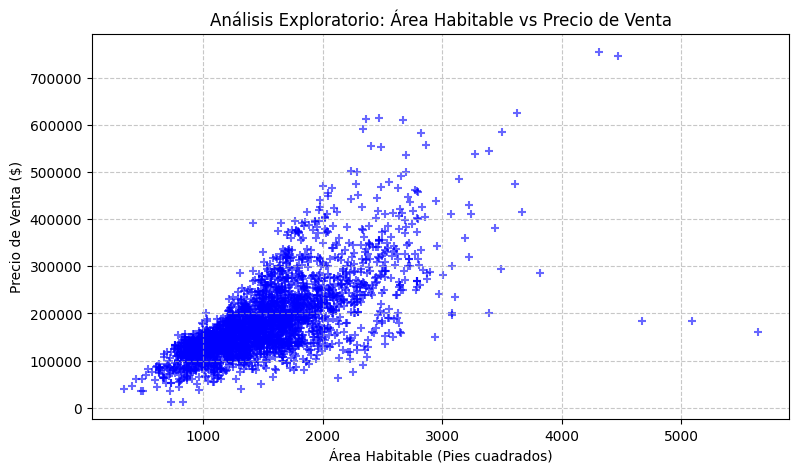

In [10]:
col_grafica = 'Gr Liv Area' if 'Gr Liv Area' in df.columns else df.columns[0]

plt.figure(figsize=(9,5))
plt.scatter(df[col_grafica], df['SalePrice'], marker='+', c='blue', alpha=0.6)
plt.title('Análisis Exploratorio: Área Habitable vs Precio de Venta')
plt.xlabel('Área Habitable (Pies cuadrados)')
plt.ylabel('Precio de Venta ($)')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()